# Leitura da base de dados

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [40]:
df = pd.read_csv('arquivo_projeto1.csv', sep=',', encoding='utf-8', decimal='.')

In [41]:
df.head() # leitura simples do arquivo CSV, mostrando as primeiras linhas do DataFrame

,ID_CLIENTE,NOME_CLIENTE,STATUS_PEDIDO,ORDER_ID,TOTAL_PEDIDO,NOME_PRODUTO
0,2,Roy White,COMPLETE,5,16.95,Women's Jacket (Blue)
1,49,Kaija Crawford,COMPLETE,19,39.16,Boy's Coat (Brown)
2,49,Kaija Crawford,COMPLETE,19,193.56,Boy's Sweater (Red)
3,144,Sharla Topper,COMPLETE,21,122.76,Boy's Shorts (Blue)
4,126,Nella Rupnick,COMPLETE,26,52.28,Women's Skirt (Brown)


# Análise da base

In [42]:
df.info() # informações sobre o DataFrame, incluindo tipos de dados e valores nulos
# df.dtypes ,tipos de dados das colunas do DataFrame so que com o df.info() é mais completo, pois mostra também a contagem de valores não nulos e o uso de memória

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256 entries, 0 to 255
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID_CLIENTE     256 non-null    int64  
 1   NOME_CLIENTE   256 non-null    object 
 2   STATUS_PEDIDO  256 non-null    object 
 3   ORDER_ID       256 non-null    int64  
 4   TOTAL_PEDIDO   256 non-null    float64
 5   NOME_PRODUTO   256 non-null    object 
dtypes: float64(1), int64(2), object(3)
memory usage: 12.1+ KB


In [43]:
df.describe() # estatísticas descritivas do DataFrame, 
# incluindo contagem, média, desvio padrão, valores mínimo e máximo, e quartis

,ID_CLIENTE,ORDER_ID,TOTAL_PEDIDO
count,256.000000,256.000000,256.000000
mean,195.441406,531.472656,75.439570
std,116.383867,278.766708,52.187881
min,1.000000,5.000000,7.180000
25%,98.000000,320.000000,37.920000
50%,198.500000,520.500000,58.740000
75%,294.000000,766.500000,104.560000
max,392.000000,980.000000,241.950000


In [44]:
df.isnull().sum() # contagem de valores nulos em cada coluna do DataFrame

ID_CLIENTE       0
NOME_CLIENTE     0
STATUS_PEDIDO    0
ORDER_ID         0
TOTAL_PEDIDO     0
NOME_PRODUTO     0
dtype: int64

In [45]:
df.duplicated().sum() # contagem de linhas duplicadas no DataFrame

0

In [46]:
df['TOTAL_PEDIDO'].value_counts() 
# mostra a contagem de valores únicos na coluna 'TOTAL_PEDIDO' do DataFrame

TOTAL_PEDIDO
153.36    5
74.13     5
97.84     4
14.36     4
186.70    4
         ..
218.55    1
59.10     1
49.00     1
26.18     1
20.48     1
Name: count, Length: 147, dtype: int64

# Gráficos 

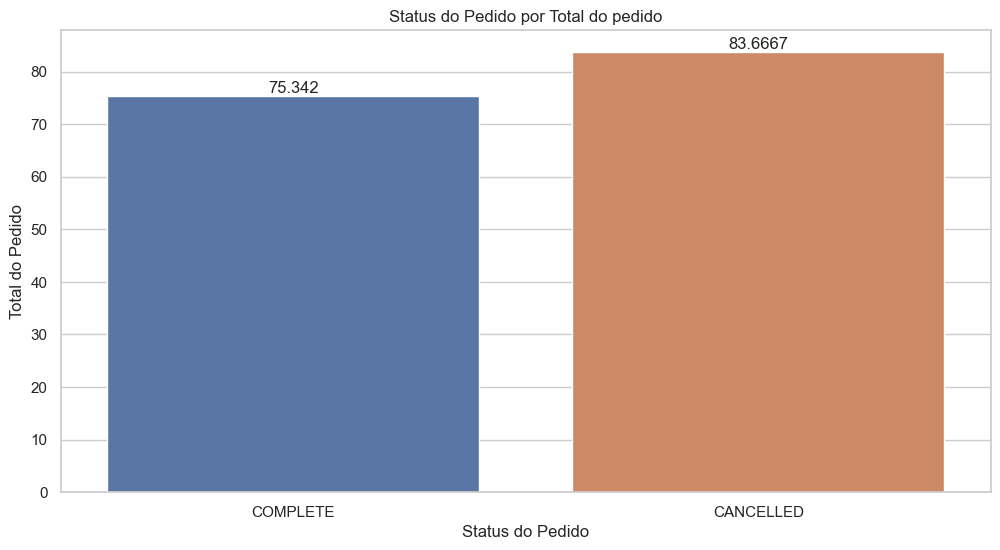

In [ ]:
sns.set_theme(style="whitegrid") # serve para definir o estilo do gráfico, nesse caso, um grid branco.
plt.figure(figsize=(12, 6)) # define o tamanho da figura do gráfico 

ax = sns.barplot(
    x=df['STATUS_PEDIDO'],
    y=df['TOTAL_PEDIDO'],
    hue=df['STATUS_PEDIDO'], # serve para definir a cor das barras do gráfico com base na coluna 'STATUS_PEDIDO'
    errorbar=None,  # remove as barras de erro do gráfico
)
plt.title('Status do Pedido por Total do pedido') # define o título do gráfico
plt.xlabel('Status do Pedido') # define o rótulo do eixo x
plt.ylabel('Total do Pedido') # define o rótulo do eixo y
for container in ax.containers:
    ax.bar_label(container) # adiciona os rótulos das barras no gráfico
plt.show()

In [48]:
# contaguem de stautus de pedico canceled
print(f"Quantidade de pedidos cancelados: {df[df['STATUS_PEDIDO'] == 'CANCELLED'].shape[0]}")

Quantidade de pedidos cancelados: 3


# Total Pedido: 

Ele não é a quantidade é (SUM(OI.UNIT_PRICE * OI.QUANTITY) AS TOTAL_PEDIDO) vindo direto do sql é o total do valor cancelado em apenas 3 pedidos cancelado de toda a base de dados.

# Leitura da segunda base

In [49]:
df = pd.read_csv('arquivo_projeto2.csv', sep=',', encoding='utf-8', decimal='.')

In [50]:
df.head()

,STORE_ID,STORE_NAME,QTD_PRODUTOS,ESTOQUE_TOTAL
0,1,Online,46,347
1,17,Perth,15,111
2,21,Bejing,21,139
3,18,São Paulo,22,142
4,22,Tokyo,13,99


qtd_produtos é apenas a contaguem distinta de produtos (COUNT(DISTINCT I.PRODUCT_ID) AS QTD_PRODUTOS).

In [51]:
df.info() # informações sobre o DataFrame, incluindo tipos de dados e valores nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   STORE_ID       23 non-null     int64 
 1   STORE_NAME     23 non-null     object
 2   QTD_PRODUTOS   23 non-null     int64 
 3   ESTOQUE_TOTAL  23 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 868.0+ bytes


In [52]:
df.duplicated().sum() # contagem de linhas duplicadas no DataFrame

0

<function matplotlib.pyplot.show(close=None, block=None)>

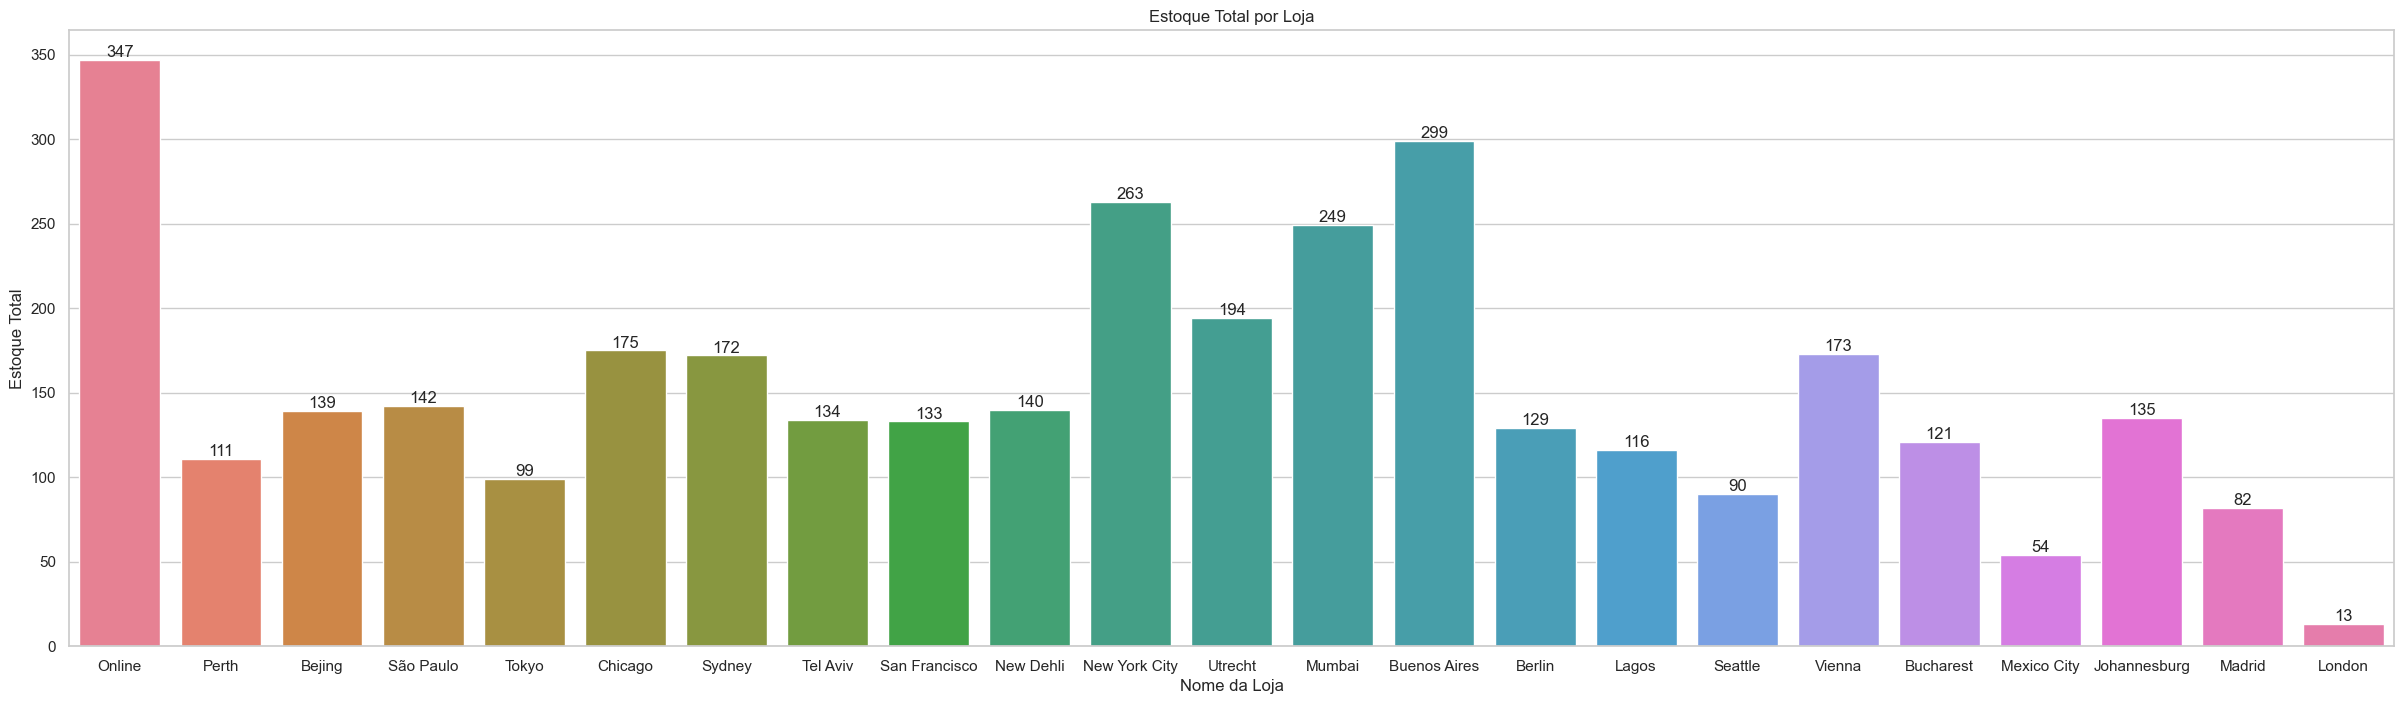

In [55]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(30, 8))

ax = sns.barplot(
    x=df['STORE_NAME'],
    y=df['ESTOQUE_TOTAL'],
    hue=df['STORE_NAME'],
    errorbar=None,  # remove as barras de erro do gráfico
)
plt.title('Estoque Total por Loja') # define o título do gráfico
plt.xlabel('Nome da Loja') # define o rótulo do eixo x  
plt.ylabel('Estoque Total') # define o rótulo do eixo y
for container in ax.containers:
    ax.bar_label(container) # adiciona os rótulos das barras no gráfico
plt.show